# Introduksjon til maskinlæring 🚀

Velkommen! Denne notebooken skal gi deg en praktisk innføring i maskinlæring, helt uten at du selv trenger å skrive noe kode. All koden er allerede skrevet — du skal bare **trykke deg gjennom cellene i rekkefølge**.

**Slik gjør du det:**
- Klikk på en celle og trykk `Shift + Enter`, eller trykk på 'Execute cell'-tegnet ved siden av hver celle, for å kjøre den og hoppe til neste.
- Kodeceller (grå bakgrunn) inneholder Python-kode og produserer en output (tabell, tall eller figur) rett under seg.
- Tekstceller (som denne) forklarer hva som skjer og hva du bør legge merke til i outputen.

Ta deg god tid til å lese forklaringene og se på figurene før du går videre — poenget er å forstå *hvorfor*, ikke bare å se koden kjøre.

## Hva er maskinlæring? 🤖

Maskinlæring handler om å la en datamaskin **finne mønstre i data selv**, i stedet for at vi programmerer alle reglene manuelt. Vi gir modellen mange eksempler, og den lærer å generalisere fra disse til nye, ukjente eksempler.

Det finnes to hovedtyper av maskinlæring, og i denne notebooken skal du prøve begge:

| Type | Har vi en fasit (target)? | Oppgave | Datasett vi bruker |
|---|---|---|---|
| **Supervised learning** (veiledet læring) | Ja | **Klassifisering**: forutsi en kategori | `cancer.csv` |
| **Supervised learning** (veiledet læring) | Ja | **Regresjon**: forutsi et tall | `energy.csv` |
| **Unsupervised learning** (ikke-veiledet læring) | Nei | **Klustering**: finne grupper i dataen | `pokemon.csv` |

- Ved **supervised learning** trener vi modellen på data der vi allerede vet fasiten (target-variabelen), slik at modellen kan lære sammenhengen mellom input (features) og output (target). Deretter tester vi om den klarer å forutsi fasiten på data den ikke har sett før.
  - Er fasiten en **kategori** (f.eks. syk/frisk), kaller vi det **klassifisering**.
  - Er fasiten et **tall** (f.eks. temperatur, pris), kaller vi det **regresjon**.
- Ved **unsupervised learning** har vi ingen fasit. Vi ber i stedet modellen finne struktur eller grupper i dataen på egen hånd — dette kalles gjerne **klustering**.

Notebooken er delt i tre deler som hver dekker én av disse oppgavene. La oss sette i gang!

## Oppsett

Først laster vi inn de Python-bibliotekene vi trenger gjennom hele notebooken:

- **pandas** og **numpy** — for å lese inn og jobbe med data i tabellform.
- **matplotlib** og **seaborn** — for å lage figurer og grafer.
- **scikit-learn (sklearn)** — biblioteket som gir oss de faktiske maskinlæringsmodellene, samt verktøy for å dele data og evaluere resultater.

Trykk `Shift + Enter` på cellen under for å kjøre den.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

print("Alt er klart! Bibliotekene er lastet inn.")

Alt er klart! Bibliotekene er lastet inn.


---
# Del 1: Supervised learning — Klassifisering

I klassifisering forsøker modellen å plassere hvert datapunkt i én av flere **kategorier**. Klassiske eksempler er spam/ikke spam, eller — som her — **godartet/ondartet svulst**.

**Datasettet:** `cancer.csv` inneholder målinger fra celleprøver hos pasienter. Hver rad er én pasient/prøve, beskrevet med flere egenskaper (features) som alle er skalert til et tall mellom 1 og 10. Target-variabelen er:

- **`Class`**: `0` = godartet (benign), `1` = ondartet (malignant)

Målet vårt er å bygge en modell som, basert på celle-målingene, kan forutsi om en svulst er godartet eller ondartet.

## 1.1 Last inn og utforsk dataen

Vi starter alltid med å se på dataen før vi gjør noe annet — det gir oss en følelse av hva vi jobber med.

In [34]:
df_cancer = pd.read_csv("cancer.csv")
print("Antall rader og kolonner:", df_cancer.shape)
df_cancer.head()

Antall rader og kolonner: (683, 10)


,Class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,0,5,1,1,1,2,1,3,1,1
1,0,5,4,4,5,7,10,3,2,1
2,0,3,1,1,1,2,2,3,1,1
3,0,6,8,8,1,3,4,3,7,1
4,0,4,1,1,3,2,1,3,1,1


In [35]:
df_cancer.info()

<class 'pandas.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Class        683 non-null    int64
 1   age          683 non-null    int64
 2   menopause    683 non-null    int64
 3   tumor-size   683 non-null    int64
 4   inv-nodes    683 non-null    int64
 5   node-caps    683 non-null    int64
 6   deg-malig    683 non-null    int64
 7   breast       683 non-null    int64
 8   breast-quad  683 non-null    int64
 9   irradiat     683 non-null    int64
dtypes: int64(10)
memory usage: 53.5 KB


Alle kolonnene er tall, og det er ingen manglende verdier (missing values) — dataen er allerede ryddet for oss. Kolonnene er:

- `Class` — target: 0 = godartet, 1 = ondartet
- `age`, `menopause`, `tumor-size`, `inv-nodes`, `node-caps`, `deg-malig`, `breast`, `breast-quad`, `irradiat` — ulike kliniske/cellebaserte egenskaper, alle skalert 1–10

### Er dataen balansert?

Før vi trener en modell er det lurt å sjekke hvor mange eksempler vi har av hver klasse. Hvis én klasse dominerer kraftig, kan en modell "jukse" seg til høy nøyaktighet ved bare å gjette den vanligste klassen.

Class
Godartet (0)    444
Ondartet (1)    239
Name: count, dtype: int64


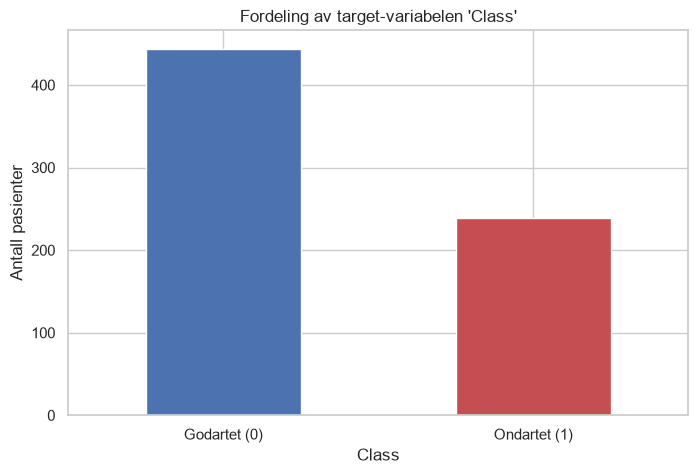

In [36]:
class_counts = df_cancer["Class"].value_counts().rename({0: "Godartet (0)", 1: "Ondartet (1)"})
print(class_counts)

class_counts.plot(kind="bar", color=["#4C72B0", "#C44E52"])
plt.title("Fordeling av target-variabelen 'Class'")
plt.ylabel("Antall pasienter")
plt.xticks(rotation=0)
plt.show()

Dataen er noe skjev (flere godartede enn ondartede tilfeller), men ikke ekstremt, det går fint å jobbe videre med.

**SPØRSMÅL:** Se på tallene og søylediagrammet over. Hvis en modell alltid gjettet "Godartet" uansett hva den fikk se, hvor høy accuracy (nøyaktighet) tror du den ville fått? Er det derfor et høyt accuracy-tall alene ikke alltid beviser at en modell er god? (Diskuter sammen)

### 🚀 ###

*Svar:* En modell som alltid gjetter "Godartet" ville hatt rett i alle de 444 godartede tilfellene, men tatt feil på alle de 239 ondartede — det gir en accuracy på om lag 444/683 ≈ 65 %, uten at modellen har lært noe som helst. Dette er grunnen til at vi senere også ser på confusion matrix og recall, ikke bare accuracy.



### Henger egenskapene sammen med target?

Et korrelasjonskart (heatmap) viser oss hvor sterkt hver egenskap henger sammen med hverandre og med `Class`. Verdier nær **1** betyr sterk positiv sammenheng, nær **-1** betyr sterk negativ sammenheng, og nær **0** betyr liten/ingen sammenheng.

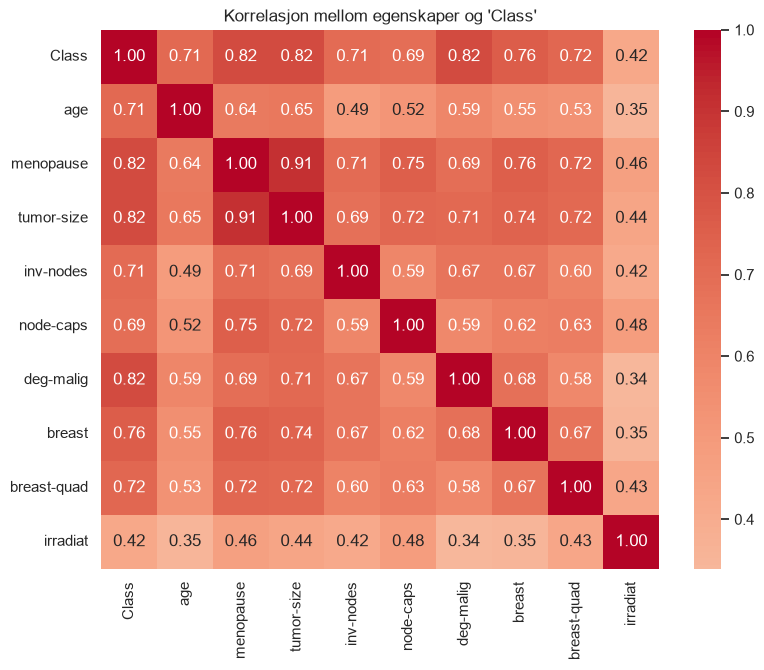

In [37]:
plt.figure(figsize=(9, 7))
sns.heatmap(df_cancer.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korrelasjon mellom egenskaper og 'Class'")
plt.show()

**Spørsmål:** Se på raden/kolonnen for `Class` i heatmapet. Hvilken egenskap har tallmessig sterkest sammenheng med `Class`? Tenk gjennom hvorfor akkurat denne egenskapen gir mening klinisk, ut fra navnet.

### 🚀 ###

*Svar:* 'Class' har sterkest tallmessig sammenheng med 'Class' som gir mening fordi det er samme variabel. `deg-malig` (malignitetsgrad) ser ut til å henge tydelig sammen med `Class` — det gir god klinisk mening, siden denne egenskapen nettopp beskriver hvor "aggressiv" svulsten ser ut.

## 1.2 Del i trening og test

For å vite om modellen faktisk **lærer**, og ikke bare "pugger" svarene, deler vi dataen i to:

- **Treningssett** (typisk 80 %): dataen modellen får lære av.
- **Testsett** (typisk 20 %): data modellen *aldri* ser under trening, som vi bruker til å sjekke hvor godt den generaliserer til nye eksempler.

Vi bruker `stratify=y` for å sikre at andelen godartet/ondartet er lik i begge settene.

In [38]:
X = df_cancer.drop(columns=["Class"])
y = df_cancer["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Treningssett:", X_train.shape)
print("Testsett:    ", X_test.shape)

Treningssett: (546, 9)
Testsett:     (137, 9)


## 1.3 Tren en modell: Beslutningstre (Decision Tree)

Et **beslutningstre** klassifiserer ved å stille en serie ja/nei-spørsmål om egenskapene, litt som et flytskjema — "Er `deg-malig` > 3.5? Hvis ja, gå til venstre, ellers til høyre" — helt til den lander på en klasse. Dette gjør modellen lett å forstå og visualisere, som passer bra når vi lærer.

Vi begrenser treet til maks 3 nivåer dypt (`max_depth=3`) slik at det holder seg oversiktlig.

In [39]:
tree_model = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
tree_model.fit(X_train, y_train)

print("Modellen er trent!")

Modellen er trent!


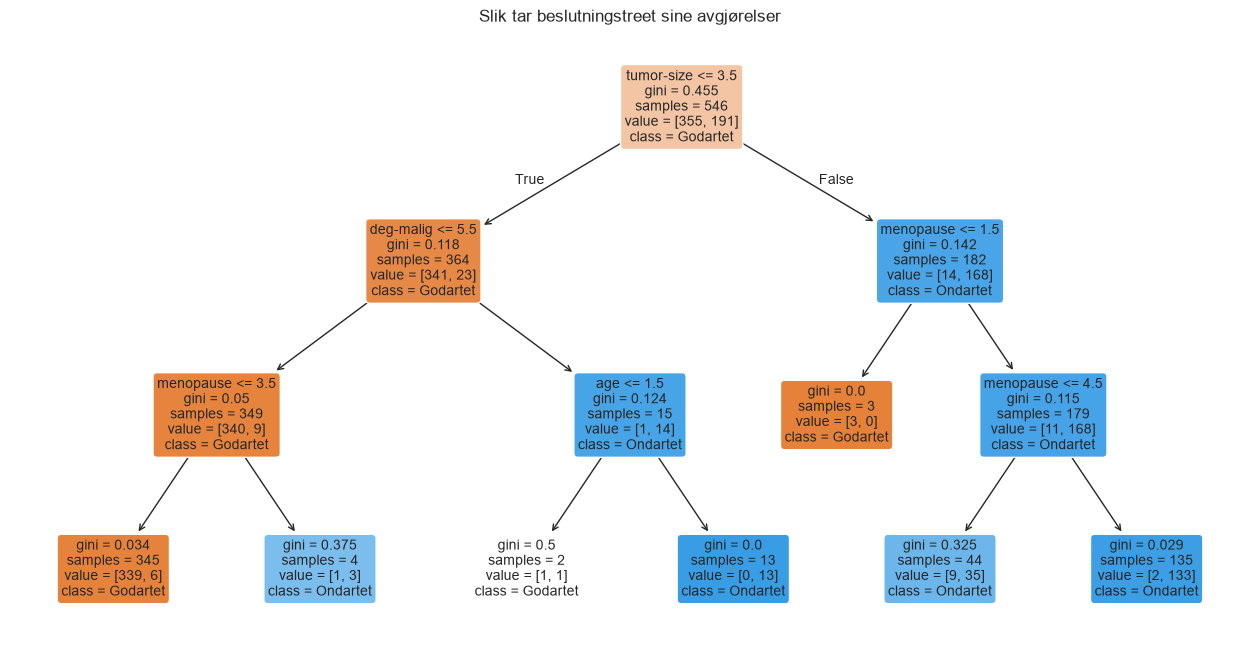

In [40]:
plt.figure(figsize=(16, 8))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Godartet", "Ondartet"],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Slik tar beslutningstreet sine avgjørelser")
plt.show()

**SPØRSMÅL:** Se på boksen helt øverst i treet (roten). Hvilken egenskap stiller den spørsmål om? Er det samme egenskap som du identifiserte som viktigst i korrelasjonskartet like ovenfor?

### 🚀 ###

*Svar:* Treet velger som regel egenskapen som best skiller de to klassene fra hverandre først, og det er ofte nettopp `deg-malig` som havner øverst, i tråd med det sterke utslaget den hadde i korrelasjonskartet.

Les treet ovenfra og ned: hver boks stiller et spørsmål om én egenskap. Er svaret sant, følger vi pilen til venstre, ellers til høyre. Fargen viser hvilken klasse boksen "heller mot" (blå = godartet, oransje = ondartet), og `value` viser det faktiske antallet trenings-eksempler av hver klasse i den boksen.

## 1.4 Evaluer modellen på testsettet

Nå er det sannhetens øyeblikk: hvor godt presterer modellen på data den aldri har sett?

- **Accuracy (nøyaktighet)**: andel riktige prediksjoner totalt.
- **Confusion matrix (forvirringsmatrise)**: viser i detalj hva modellen traff og bommet på — hvor mange godartede ble korrekt gjettet som godartet, hvor mange ondartede ble feilaktig gjettet som godartet, osv.

In [ ]:
y_pred = tree_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Nøyaktighet (accuracy) på testsettet: {accuracy:.1%}")

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Godartet", "Ondartet"],
    yticklabels=["Godartet", "Ondartet"],
)
plt.xlabel("Modellens prediksjon")
plt.ylabel("Faktisk klasse")
plt.title("Confusion matrix")
plt.show()

**SPØRMSÅL:** Se på matrisen. Hvor mange pasienter ble feilklassifisert totalt? Er det flest feil der modellen sa "Godartet" men fasiten var "Ondartet", eller omvendt? Hvorfor tror du den ene typen feil er farligere enn den andre i en medisinsk sammenheng?

### 🚀 ###

*Svar:* Diagonalen (øverst til venstre og nederst til høyre) viser antall **riktige** prediksjoner. Alt utenfor diagonalen er feil — og i medisinske sammenhenger er det spesielt viktig å se på hvor mange ondartede tilfeller som feilaktig ble gjettet som godartede (såkalte "falske negative"), siden det er den farligste feilen å gjøre: en pasient risikerer da å ikke få behandling hun trenger.

Under viser vi også en mer detaljert rapport med **precision** (av de modellen sa var ondartet, hvor mange var det faktisk?) og **recall** (av alle faktisk ondartede, hvor mange fant modellen?).

In [ ]:
print(classification_report(y_test, y_pred, target_names=["Godartet", "Ondartet"]))

### Hvilke egenskaper betydde mest?

Beslutningstreet kan fortelle oss hvor viktig hver egenskap var for prediksjonene.

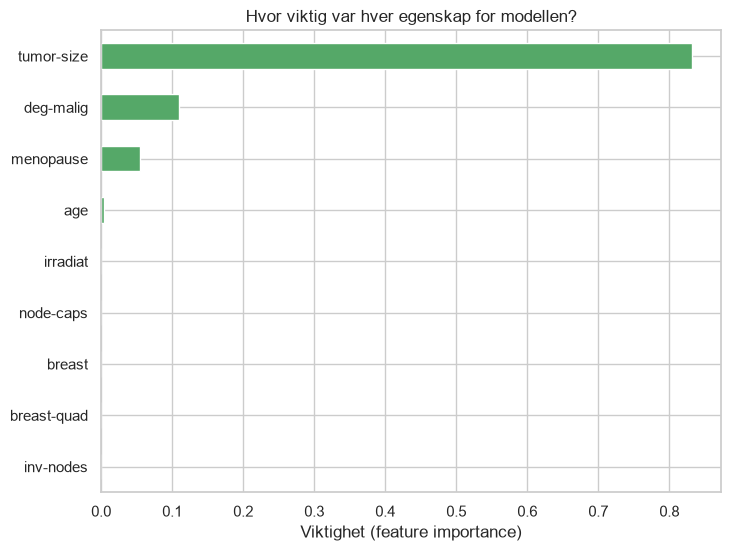

In [41]:
importances = pd.Series(tree_model.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="#55A868")
plt.title("Hvor viktig var hver egenskap for modellen?")
plt.xlabel("Viktighet (feature importance)")
plt.show()

**SPØRSMÅL:** Stemmer rangeringen i figuren over med egenskapen du trodde ville bli viktigst da du så på korrelasjonskartet og roten av treet tidligere? Er det noen overraskelser?

### Test modellen på ett enkelt eksempel

La oss se konkret på én pasient fra testsettet: hva var egenskapene, hva gjettet modellen, og hva var fasiten?

In [42]:
i = 0
example = X_test.iloc[[i]]
sann_klasse = y_test.iloc[i]
predikert_klasse = tree_model.predict(example)[0]
sannsynligheter = tree_model.predict_proba(example)[0]

print("Egenskaper for pasienten:")
print(example.T)
print()
print(f"Faktisk klasse:    {'Ondartet' if sann_klasse == 1 else 'Godartet'}")
print(f"Modellens gjetning: {'Ondartet' if predikert_klasse == 1 else 'Godartet'}")
print(f"Modellens sikkerhet: {sannsynligheter.max():.1%}")

Egenskaper for pasienten:
             175
age            1
menopause      1
tumor-size     1
inv-nodes      1
node-caps      2
deg-malig      1
breast         1
breast-quad    1
irradiat       1

Faktisk klasse:    Godartet
Modellens gjetning: Godartet
Modellens sikkerhet: 98.3%


### Oppsummering — Del 1

- Vi trente en **klassifiseringsmodell** (beslutningstre) til å forutsi om en svulst er godartet eller ondartet, basert på celle-målinger.
- Vi delte dataen i trening og test for å kunne måle hvor godt modellen generaliserer.
- Vi evaluerte modellen med **accuracy**, **confusion matrix** og **precision/recall** — ikke bare ett enkelt tall.
- Vi så at noen egenskaper (som `deg-malig`) var langt viktigere enn andre for modellens beslutninger.

Neste steg: hva om target-variabelen er et **tall** i stedet for en kategori? Da går vi over til regresjon.

---
# Del 2: Supervised learning — Regresjon

I regresjon forsøker modellen å forutsi et **kontinuerlig tall**, i stedet for en kategori. I stedet for "godartet eller ondartet" spør vi nå "*hvor mye*?".

**Datasettet:** `energy.csv` inneholder data om ulike bygningsdesign — form, størrelse og materialbruk — og hvor mye energi bygningen trenger til oppvarming og kjøling. Vi har to mulige target-variabler:

- **`Heating Load`** — energibehov til oppvarming
- **`Cooling Load`** — energibehov til kjøling

Vi bygger først en modell for `Heating Load`, og viser til slutt at akkurat samme oppskrift kan gjenbrukes for `Cooling Load`.

## 2.1 Last inn og utforsk dataen

In [ ]:
df_energy = pd.read_csv("energy.csv")
print("Antall rader og kolonner:", df_energy.shape)
df_energy.head()

In [ ]:
df_energy.describe()

Kolonnene beskriver bygningens form og design:

- `Relative Compactness`, `Surface Area`, `Wall Area`, `Roof Area`, `Overall Height` — bygningens geometri
- `Orientation` — hvilken retning bygget vender
- `Glazing Area`, `Glazing Area Distribution` — mengde og fordeling av vindusglass
- `Heating Load`, `Cooling Load` — energibehov (målt i kWh/m²) — dette er de to mulige target-variablene

### Hvordan ser target-variabelen ut?

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df_energy["Heating Load"], bins=30, kde=True, color="#DD8452")
plt.title("Fordeling av Heating Load")
plt.xlabel("Heating Load (kWh/m²)")
plt.show()

**SPØRSMÅL:** Ser fordelingen symmetrisk ut, eller er den skjev? Er det flest bygninger med lavt eller høyt energibehov?

### Hvilke egenskaper henger sammen med Heating Load?

Akkurat som i klassifiseringsdelen bruker vi et korrelasjonskart for å se hvilke egenskaper som ser ut til å påvirke energibehovet mest.

In [ ]:
plt.figure(figsize=(9, 7))
sns.heatmap(df_energy.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korrelasjon mellom egenskaper og energibehov")
plt.show()

**SPØRSMÅL:** Hvilke to egenskaper ser ut til å ha sterkest sammenheng (positiv eller negativ) med `Heating Load`? Gir det mening ut fra hva du vet om hvordan bygninger holder på varme?

### 🚀 ###

*Svar:* Legg merke til at `Overall Height` har en sterk **positiv** sammenheng med `Heating Load` (høyere bygg → mer oppvarmingsbehov), mens `Roof Area` har en sterk **negativ** sammenheng (større takflate → mindre oppvarmingsbehov). Dette er nettopp den typen mønstre en regresjonsmodell skal lære å utnytte.

Merk også at `Heating Load` og `Cooling Load` henger tett sammen med hverandre — det gir mening, men det betyr at vi **ikke** kan bruke `Cooling Load` som en egenskap (feature) når vi skal forutsi `Heating Load`. Det ville vært juks, siden vi normalt ikke ville kjent kjølebehovet på forhånd heller — begge er jo ting vi ønsker å forutsi.

## 2.2 Del i trening og test

Samme prinsipp som i Del 1: vi trener på 80 % av dataen og tester på de resterende 20 %. Vi fjerner både `Heating Load` og `Cooling Load` fra egenskapene (X), siden begge er target-kandidater.

In [ ]:
X = df_energy.drop(columns=["Heating Load", "Cooling Load"])
y = df_energy["Heating Load"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Treningssett:", X_train.shape)
print("Testsett:    ", X_test.shape)

## 2.3 Tren en modell: Lineær regresjon

**Lineær regresjon** forsøker å finne den beste rette linjen (eller, med flere egenskaper: det beste "planet") gjennom dataen. Modellen lærer seg en vekt (koeffisient) for hver egenskap, og legger dem sammen til en prediksjon:

`Heating Load ≈ vekt1 × egenskap1 + vekt2 × egenskap2 + ... + konstant`

In [ ]:
linreg_model = LinearRegression()
linreg_model.fit(X_train, y_train)

print("Modellen er trent!")

## 2.4 Evaluer modellen på testsettet

For regresjon bruker vi andre mål enn for klassifisering, siden "riktig/feil" ikke gir mening når vi forutsier et tall — vi er heller interessert i **hvor langt unna** prediksjonen var:

- **MAE (Mean Absolute Error)**: gjennomsnittlig avvik mellom prediksjon og fasit, i samme enhet som target (kWh/m²).
- **RMSE (Root Mean Squared Error)**: ligner MAE, men straffer store feil hardere.
- **R² (forklart varians)**: hvor stor andel av variasjonen i target modellen klarer å forklare. 1.0 = perfekt, 0.0 = ikke bedre enn å bare gjette gjennomsnittet.

In [ ]:
y_pred = linreg_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f} kWh/m²")
print(f"RMSE: {rmse:.2f} kWh/m²")
print(f"R²:   {r2:.3f}")

### Prediksjon vs. fasit

Den beste måten å se hvor godt modellen presterer på, er å plotte modellens prediksjoner mot de faktiske verdiene. Jo nærmere punktene ligger den stiplede diagonale linjen, jo bedre er modellen — punkter på linjen betyr at prediksjon = fasit.

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="#4C72B0")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "--", color="gray", label="Perfekt prediksjon")

plt.xlabel("Faktisk Heating Load")
plt.ylabel("Predikert Heating Load")
plt.title("Predikert vs. faktisk energibehov")
plt.legend()
plt.show()

**SPØRSMÅL:** Hvis et punkt ligger godt over den stiplede linjen, har modellen da overvurdert eller undervurdert energibehovet for den bygningen? Ligger punktene jevnt fordelt rundt linjen, eller ser du et mønster (f.eks. at modellen bommer mer på høye verdier)?

### Hvilke egenskaper vektlegger modellen mest?

Koeffisientene forteller oss hvor mye — og i hvilken retning — hver egenskap påvirker prediksjonen.

In [43]:
coefficients = pd.Series(linreg_model.coef_, index=X.columns).sort_values()

plt.figure(figsize=(8, 6))
coefficients.plot(kind="barh", color="#C44E52")
plt.title("Modellens koeffisienter (vekter) per egenskap")
plt.xlabel("Koeffisient")
plt.show()

ValueError: Length of values (8) does not match length of index (9)

**SPØRSMÅL:** Har `Overall Height` en positiv eller negativ koeffisient? Stemmer fortegnet (+/-) overens med korrelasjonen du så i heatmapet tidligere?

### Bonus: Samme oppskrift for Cooling Load

Legg merke til hvor lite som skal til for å trene en helt ny modell for `Cooling Load` — vi gjenbruker akkurat samme fremgangsmåte, bare med en annen target-variabel.

In [ ]:
y_cooling = df_energy["Cooling Load"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_cooling, test_size=0.2, random_state=RANDOM_STATE
)

cooling_model = LinearRegression()
cooling_model.fit(X_train_c, y_train_c)
y_pred_c = cooling_model.predict(X_test_c)

print(f"R² for Cooling Load: {r2_score(y_test_c, y_pred_c):.3f}")

**SPØRSMÅL:** Ble R² høyere eller lavere enn for `Heating Load`? Husk at `Heating Load` og `Cooling Load` var sterkt korrelerte i heatmapet tidligere — hvorfor gir det mening at en modell som er god på den ene, ofte også er god på den andre?

### Oppsummering — Del 2

- Vi trente en **regresjonsmodell** (lineær regresjon) til å forutsi et kontinuerlig energibehov, i stedet for en kategori.
- Vi brukte **MAE**, **RMSE** og **R²** for å evaluere modellen — ikke accuracy, siden "riktig/feil" ikke gir mening for tallprediksjon.
- Vi så hvordan koeffisientene forteller oss hvilke egenskaper som driver prediksjonen, og i hvilken retning.
- Vi gjenbrukte hele oppskriften på en ny target-variabel (`Cooling Load`) med minimal ekstra innsats.

Til nå har vi alltid hatt en fasit å trene mot. Hva gjør vi når vi **ikke** har noen fasit i det hele tatt?

---
# Del 3: Unsupervised learning — Klustering

Nå snur vi problemet på hodet. I **unsupervised learning** har vi ingen fasit (target) å trene mot — vi har bare egenskaper (features), og ber modellen finne **struktur eller grupper** i dataen på egen hånd.

**Datasettet:** `pokemon.csv` inneholder statistikk for 800 Pokémon — angrep, forsvar, liv, hastighet, osv. Det finnes ingen "riktig" gruppe å plassere hver Pokémon i på forhånd. I stedet skal vi bruke **klustering** til å la algoritmen selv oppdage hvilke Pokémon som ligner på hverandre, basert på kampstatistikken deres.

## 3.1 Last inn og utforsk dataen

In [46]:
df_pokemon = pd.read_csv("pokemon.csv")
print("Antall rader og kolonner:", df_pokemon.shape)
df_pokemon.head(10)

Antall rader og kolonner: (800, 13)


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False
9,7,Squirtle,Water,NaN,314,44,48,65,50,64,43,1,False


In [45]:
df_pokemon.isna().sum()

#               0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

**SPØRSMÅL:** Hvorfor tror du det akkurat er `Type 2` som mangler verdier, og ikke f.eks. `Type 1` eller `HP`?

### 🚀 ###

*Svar:* `Type 2` mangler for mange Pokémon — det er helt naturlig, siden mange Pokémon bare har **én** type (f.eks. bare "Fire"), mens andre har to (f.eks. "Fire"/"Flying"). Dette er altså ikke et datafeil, og vi trenger ikke fikse det, siden vi uansett ikke skal bruke typene i klusteringen.

### Hvilke egenskaper skal vi kluster på?

Vi bruker de seks kampstatistikkene som beskriver hver Pokémons styrker og svakheter:
`HP`, `Attack`, `Defense`, `Sp. Atk`, `Sp. Def`, `Speed`.

In [47]:
stat_cols = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
df_pokemon[stat_cols].describe()

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500
std,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474
min,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000
25%,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000
50%,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000
75%,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000
max,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000


## 3.2 Skaler dataen

Klustering baserer seg på å måle **avstand** mellom datapunkter. Hvis én egenskap har mye større tallverdier enn en annen, vil den dominere avstandsberegningen — selv om den egentlig ikke er viktigere. Derfor **standardiserer** vi alle egenskapene til samme skala (gjennomsnitt 0, standardavvik 1) før vi kjører klustering.

In [48]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pokemon[stat_cols])

print("Dataen er skalert. Eksempel på de tre første radene:")
pd.DataFrame(X_scaled[:3], columns=stat_cols).round(2)

Dataen er skalert. Eksempel på de tre første radene:


,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,-0.95,-0.92,-0.80,-0.24,-0.25,-0.80
1,-0.36,-0.52,-0.35,0.22,0.29,-0.29
2,0.42,0.09,0.29,0.83,1.01,0.40


## 3.3 Hvor mange grupper (k) skal vi lete etter?

Algoritmen vi skal bruke, **K-Means**, krever at vi på forhånd bestemmer hvor mange klustre (`k`) den skal dele dataen i. Men hvordan velger vi et fornuftig antall?

Vi bruker **albue-metoden (elbow method)**: vi prøver ulike verdier for `k`, og måler hvor "tett" hvert kluster er (kalt *inertia* — lavere er bedre, men blir alltid lavere jo flere klustre vi bruker). Vi ser etter punktet der kurven flater ut — "albuen" — som viser hvor vi får mest nytte per ekstra kluster.

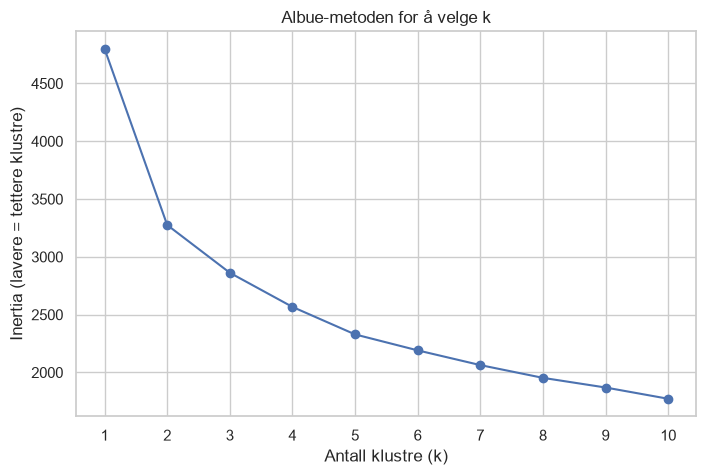

In [49]:
inertias = []
k_values = range(1, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Antall klustre (k)")
plt.ylabel("Inertia (lavere = tettere klustre)")
plt.title("Albue-metoden for å velge k")
plt.xticks(list(k_values))
plt.show()

**SPØRSMÅL:** Se på kurven. Hvor synes *du* at "albuen" (knekkpunktet der kurven flater ut) er? Hvilken k ville du valgt og hvorfor?

### 🚀 ###

*Svar:* Kurven flater tydelig ut rundt **k = 4** — etter dette punktet gir hvert ekstra kluster stadig mindre forbedring. Vi går derfor videre med **4 klustre**. Det finnes ikke ett eneste "riktig" svar her — albue-metoden er en tommelfingerregel, og k=3 eller k=5 ville også vært forsvarlige valg.

## 3.4 Kjør K-Means med valgt k

K-Means fungerer slik: den plasserer `k` "sentre" tilfeldig, tildeler hvert datapunkt til nærmeste senter, flytter deretter hvert senter til midtpunktet av sine tildelte punkter, og gjentar dette helt til ingenting endrer seg. Resultatet er `k` grupper der punktene i hver gruppe ligner mest mulig på hverandre.

In [50]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
df_pokemon["Cluster"] = kmeans.fit_predict(X_scaled)

df_pokemon["Cluster"].value_counts().sort_index()

Cluster
0    198
1    279
2    200
3    123
Name: count, dtype: int64

## 3.5 Visualiser klustrene

Vi klustret på 6 dimensjoner samtidig (HP, Attack, Defense, Sp. Atk, Sp. Def, Speed) — for mange til å plotte direkte. Vi bruker derfor **PCA (Principal Component Analysis)** til å komprimere de 6 dimensjonene ned til 2, kun for å kunne visualisere resultatet. PCA brukes altså bare til å *tegne* figuren — selve klusteringen er allerede gjort på de originale 6 dimensjonene.

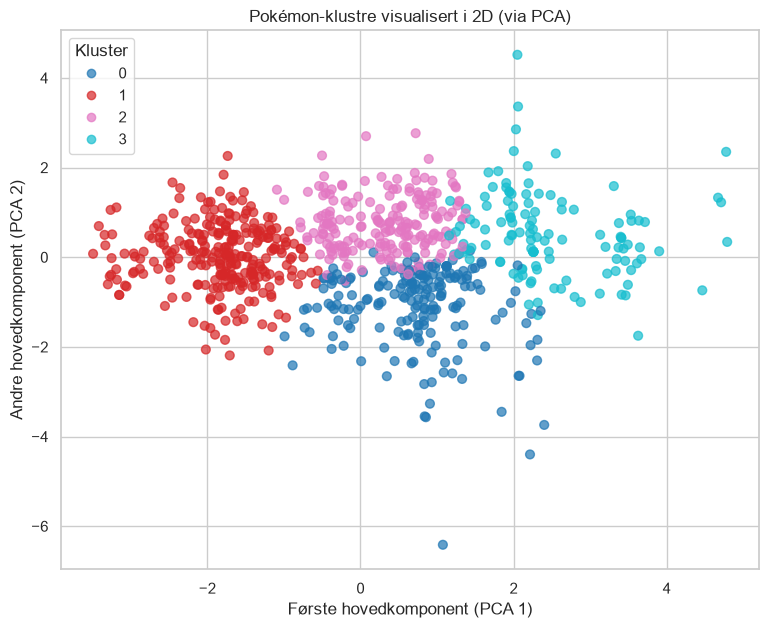

In [51]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df_pokemon["Cluster"], cmap="tab10", alpha=0.7, s=40,
)
plt.xlabel("Første hovedkomponent (PCA 1)")
plt.ylabel("Andre hovedkomponent (PCA 2)")
plt.title("Pokémon-klustre visualisert i 2D (via PCA)")
plt.legend(*scatter.legend_elements(), title="Kluster")
plt.show()

In [52]:
forklart_varians = pca.explained_variance_ratio_
print(f"PCA 1 forklarer {forklart_varians[0]:.1%} av variasjonen i dataen")
print(f"PCA 2 forklarer {forklart_varians[1]:.1%} av variasjonen i dataen")
print(f"Til sammen: {forklart_varians.sum():.1%}")

PCA 1 forklarer 45.2% av variasjonen i dataen
PCA 2 forklarer 18.2% av variasjonen i dataen
Til sammen: 63.4%


**SPØRSMÅL:** Ser klustrene ut til å være godt atskilt i figuren, eller overlapper noen av dem litt? Med tanke på at de to PCA-aksene til sammen bare forklarer en andel av den totale variasjonen (se tallet over) — hvorfor kan to punkter se "nære" ut i denne 2D-figuren, selv om de egentlig ikke lignet så mye på hverandre i de opprinnelige 6 dimensjonene?

### 🚀 ###

*Svar:* Siden PCA komprimerer 6 dimensjoner ned til 2, mister vi noe informasjon i prosessen — punkter kan derfor se nærmere hverandre ut i figuren enn de faktisk er i det fulle rommet klusteringen ble gjort i. Klustrene vil likevel som regel vise en tydelig tendens til å gruppere seg, selv om grensene ikke alltid er krystallklare i en forenklet 2D-visning.

## 3.6 Hva kjennetegner hvert kluster?

Nå som vi har delt Pokémon inn i grupper, kan vi se på gjennomsnittsstatistikken i hvert kluster for å forstå hva som kjennetegner dem.

In [53]:
cluster_profile = df_pokemon.groupby("Cluster")[stat_cols].mean().round(1)
cluster_profile["Antall"] = df_pokemon["Cluster"].value_counts().sort_index()
cluster_profile

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Antall
Cluster,,,,,,,
0,81.7,85.6,102.3,74.1,88.8,52.9,198
1,50.0,53.7,52.0,47.7,49.1,49.1,279
2,71.6,83.7,65.3,77.6,71.2,91.4,200
3,89.1,118.1,91.6,120.0,97.6,99.0,123


In [54]:
for cluster_id in sorted(df_pokemon["Cluster"].unique()):
    eksempler = df_pokemon.loc[df_pokemon["Cluster"] == cluster_id, "Name"].head(5).tolist()
    print(f"Kluster {cluster_id}: {', '.join(eksempler)}, ...")

Kluster 0: Venusaur, Wartortle, Blastoise, Sandslash, Nidoqueen, ...
Kluster 1: Bulbasaur, Charmander, Squirtle, Caterpie, Metapod, ...
Kluster 2: Ivysaur, Charmeleon, Charizard, Butterfree, Beedrill, ...
Kluster 3: VenusaurMega Venusaur, CharizardMega Charizard X, CharizardMega Charizard Y, BlastoiseMega Blastoise, PidgeotMega Pidgeot, ...


**SPØRSMÅL:** Se nøye på tabellen og navneeksemplene over, og prøv å sette et eget navn eller en beskrivelse på hvert av de fire klustrene *før* du leser videre. Hvilket kluster vil du kalle "de sterkeste"? Hvilket vil du kalle "de svakeste"? Er det noen klustre som er vanskelige å sette et enkelt navn på?

### 🚀 ###

*Forslag til tolkning:* Dette er selve poenget med unsupervised learning: **vi**, menneskene, må tolke gruppene i etterkant, siden algoritmen ikke vet noe om hva en "sterk" eller "svak" Pokémon egentlig er. Du vil typisk finne igjen mønstre som:

- Et kluster med **lave verdier over hele linjen** — ofte tidlige utviklingsstadier / svakere Pokémon.
- Et kluster med **høy Defense og HP, men lavere Speed** — "tanks" som tåler mye, men er trege.
- Et kluster med **høy Speed og Sp. Atk** — raske, offensive Pokémon.
- Et kluster med **høyt på nesten alt** — de sterkeste Pokémonene (legg gjerne merke til navnene her — dukker det opp noen Mega-utviklinger?).

### Oppsummering — Del 3

- Vi brukte **K-Means-klustering** til å finne grupper i data **uten** noen fasit å trene mot.
- Vi standardiserte dataen først, siden klustering er avstandsbasert og følsom for ulike skalaer.
- Vi brukte **albue-metoden** til å velge et fornuftig antall klustre.
- Vi brukte **PCA** til å visualisere de høy-dimensjonale klustrene i 2D.
- Til slutt tolket **vi** klustrene selv — algoritmen fant gruppene, men det er opp til oss å gi dem mening.

---
# Oppsummering: Supervised vs. unsupervised learning

| | Klassifisering | Regresjon | Klustering |
|---|---|---|---|
| **Læringstype** | Supervised | Supervised | Unsupervised |
| **Datasett** | `cancer.csv` | `energy.csv` | `pokemon.csv` |
| **Target-variabel** | `Class` (kategori) | `Heating Load` / `Cooling Load` (tall) | Ingen |
| **Modell brukt** | Decision Tree | Lineær regresjon | K-Means |
| **Output** | En av flere klasser | Et kontinuerlig tall | Gruppetilhørighet |
| **Evaluering** | Accuracy, confusion matrix, precision/recall | MAE, RMSE, R² | Inertia / albue-metoden, tolkning av grupper |

**Kjernetakeaway:** Har du en fasit å trene mot, er det supervised learning — og om fasiten er en kategori eller et tall, avgjør om det er klassifisering eller regresjon. Har du ingen fasit, men vil finne struktur i dataen, er det unsupervised learning.

---
# Oppgaver: prøv deg videre

Under følger noen oppgaver du kan jobbe videre med, enten alene eller sammen med noen andre. Noen er rene tenke-/diskusjonsoppgaver, andre ber deg gå tilbake til en kodecelle lenger opp i notebooken, endre én verdi, og kjøre cellene i den seksjonen på nytt for å se hva som skjer. Du trenger aldri å skrive kode fra bunnen av — bare justere noe som allerede står der.

## Del 1: Klassifisering (cancer.csv)

1. **Tenk:** Hvorfor holder det ikke å bare se på accuracy når dataen er skjev, slik den er her (flere godartede enn ondartede tilfeller)? Hvilke(t) av de andre målene (precision, recall) ville du stolt mest på hvis målet var å ikke overse noen ondartede tilfeller?
2. **Prøv i koden:** Gå til seksjon 1.3 og endre `max_depth=3` til `max_depth=1` og deretter til `max_depth=10`. Kjør cellene i 1.3 og 1.4 på nytt hver gang. Hva skjer med accuracy? Blir treet mer eller mindre forståelig å lese?
3. **Prøv i koden:** I den siste kodecellen i seksjon 1.4 (enkelt-eksempelet), endre `i = 0` til en annen verdi, f.eks. `i = 15`. Er modellen like sikker på denne pasienten som på den forrige?
4. **Diskuter:** Beslutningstreet er lett å lese og forstå (vi kan se nøyaktig *hvorfor* det tok en avgjørelse). Hvorfor tror du det kan være like viktig som selve nøyaktigheten i en medisinsk sammenheng?

## Del 2: Regresjon (energy.csv)

1. **Prøv i koden:** Gå til seksjon 2.2 og fjern en egenskap fra `X`, f.eks. med `X = X.drop(columns=["Orientation"])` rett etter cellen som lager `X`. Kjør resten av Del 2 på nytt — hvor mye endres R²?
2. **Tenk:** Hva ville skjedd med modellen dersom vi hadde latt `Cooling Load` være med som en egenskap (feature) for å forutsi `Heating Load`? Hvorfor kalles dette "data leakage", og hvorfor er det juks?
3. **Prøv i koden:** Endre `test_size=0.2` til `test_size=0.5` i seksjon 2.2. Blir modellen bedre eller dårligere på testsettet? Har du en teori om hvorfor?
4. **Tenk:** Hvis MAE for modellen er f.eks. 2 kWh/m² — hva betyr det konkret for en boligeier som skal budsjettere strømutgifter? Er det en feilmargin du ville stolt på?

## Del 3: Klustering (pokemon.csv)

1. **Prøv i koden:** Gå til seksjon 3.4 og endre `k = 4` til `k = 3` og deretter `k = 6`. Kjør cellene i 3.4–3.6 på nytt hver gang. Blir grupperingen mer eller mindre meningsfull?
2. **Tenk:** Vi kan ikke bruke accuracy til å evaluere klustringen, slik vi gjorde i Del 1. Hvorfor ikke? Hva er det egentlig som mangler sammenlignet med klassifisering?
3. **Prøv i koden:** Legg til `"Total"` i listen `stat_cols` i seksjon 3.1, og kjør resten av Del 3 på nytt. Endres klustrene mye, eller lite? Hvorfor tror du det blir sånn?
4. **Tenk:** Hvis du hadde forsøkt å legge til `Legendary` (som er sann/usann, ikke et tall) direkte i `stat_cols` uten å gjøre noe med den først, hva tror du ville skjedd da vi skalerte og klustret dataen?

## På tvers av alle tre

1. **Diskuter:** Hvilken av de tre oppgavetypene (klassifisering, regresjon, klustering) tror du er vanskeligst å vurdere om resultatet faktisk er "bra"? Begrunn svaret.
2. **Tenk:** Kan du komme på ett eksempel fra din egen hverdag, studie eller jobb som ville passe til hver av de tre oppgavetypene?
3. **Diskuter:** Alle tre modellene vi brukte (beslutningstre, lineær regresjon, K-Means) er blant de enkleste som finnes innen maskinlæring. Hvorfor tror du det likevel er lurt å starte med enkle modeller, fremfor å gå rett på de mest avanserte?

Lykke til videre med maskinlæring!